In [ ]:
import os
import zipfile
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

# --- Config ---
BASE_URL = "https://s3.eu-central-1.amazonaws.com/avg-kitti"
DEST_DIR = "/content/kitti"          # change to a Drive path to persist across sessions
MAX_WORKERS = 4                       # concurrent downloads; S3 handles this fine
DELETE_ZIP_AFTER_EXTRACT = True

FILES = [
    # Object detection benchmark
    "data_object_image_2.zip",
    "data_object_label_2.zip",
    "data_object_calib.zip",
    "data_object_velodyne.zip",
    # Tracking benchmark
    "data_tracking_image_2.zip",
    "data_tracking_label_2.zip",
    "data_tracking_calib.zip",
]

os.makedirs(DEST_DIR, exist_ok=True)


def download_file(filename):
    url = f"{BASE_URL}/{filename}"
    dest_path = os.path.join(DEST_DIR, filename)

    if os.path.exists(dest_path):
        return f"Skipped (already exists): {filename}"

    response = requests.get(url, stream=True)
    response.raise_for_status()
    total_size = int(response.headers.get("content-length", 0))

    with open(dest_path, "wb") as f, tqdm(
        total=total_size,
        unit="B",
        unit_scale=True,
        unit_divisor=1024,
        desc=filename,
        leave=True,
    ) as bar:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
            bar.update(len(chunk))

    return f"Downloaded: {filename}"



# --- Step 1: Download concurrently ---
print("Downloading files...")
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(download_file, f): f for f in FILES}
    for future in as_completed(futures):
        try:
            print(future.result())
        except Exception as e:
            print(f"Failed to download {futures[future]}: {e}")



In [8]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import os
import shutil
from tqdm.auto import tqdm

def copy_zips_with_progress(src, dst):
    os.makedirs(dst, exist_ok=True)

    # Only grab .zip files, anywhere under src
    zip_files = []
    for root, dirs, files in os.walk(src):
        for f in files:
            if f.endswith('.zip'):
                zip_files.append(os.path.join(root, f))

    if not zip_files:
        print("No zip files found under", src)
        return

    total_size = sum(os.path.getsize(f) for f in zip_files)

    with tqdm(total=total_size, unit='B', unit_scale=True, unit_divisor=1024, desc="Copying zips to Drive") as pbar:
        for file_path in zip_files:
            filename = os.path.basename(file_path)
            dest_path = os.path.join(dst, filename)
            shutil.copy2(file_path, dest_path)
            pbar.update(os.path.getsize(file_path))

    print(f"\nCopied {len(zip_files)} zip files to {dst}")

copy_zips_with_progress('/content/kitti', '/content/drive/MyDrive/kitti_zips')

No zip files found under /content/kitti


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#

Mounted at /content/drive


In [10]:
import os
import shutil
from tqdm.auto import tqdm

def copy_zips_from_drive(src, dst):
    os.makedirs(dst, exist_ok=True)

    zip_files = []
    for root, dirs, files in os.walk(src):
        for f in files:
            if f.endswith('.zip'):
                zip_files.append(os.path.join(root, f))

    if not zip_files:
        print("No zip files found under", src)
        return

    total_size = sum(os.path.getsize(f) for f in zip_files)

    with tqdm(total=total_size, unit='B', unit_scale=True, unit_divisor=1024, desc="Copying zips to Colab disk") as pbar:
        for file_path in zip_files:
            filename = os.path.basename(file_path)
            dest_path = os.path.join(dst, filename)
            shutil.copy2(file_path, dest_path)
            pbar.update(os.path.getsize(file_path))

    print(f"\nCopied {len(zip_files)} zip files to {dst}")

copy_zips_from_drive('/content/drive/MyDrive/kitti_zips', '/content/kitti')

Copying zips to Colab disk:   0%|          | 0.00/53.2G [00:00<?, ?B/s]


Copied 7 zip files to /content/kitti


In [11]:
import zipfile

extract_root = '/content/kitti'
for f in os.listdir(extract_root):
    if f.endswith('.zip'):
        zip_path = os.path.join(extract_root, f)
        extract_dir = os.path.join(extract_root, f.replace('.zip', ''))
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(extract_dir)
        print(f"Extracted {f}")

Extracted data_object_calib.zip
Extracted data_object_label_2.zip
Extracted data_object_image_2.zip
Extracted data_tracking_label_2.zip
Extracted data_tracking_image_2.zip
Extracted data_object_velodyne.zip
Extracted data_tracking_calib.zip


In [3]:

%pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [ ]:
import random
import shutil
from pathlib import Path
from PIL import Image
import torch
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Point this at wherever your extracted KITTI folders live in Colab,
# e.g. /content/kitti if that's your working dir.
ROOT = Path("/content/kitti")

IMG_DIR   = ROOT / "data_object_image_2" / "training" / "image_2"
LABEL_DIR = ROOT / "data_object_label_2" / "training" / "label_2"
OUT_DIR   = ROOT / "yolo_kitti"

MODEL       = "yolo11x.pt"
EPOCHS      = 50
IMGSZ       = 640
BATCH       = 16
VAL_SPLIT   = 0.1
SEED        = 42
SKIP_PREPARE   = False   # set True to reuse an existing ./yolo_kitti/ split
PREPARE_ONLY   = False   # set True to just build the dataset, skip training

In [ ]:
# KITTI has 9 label types. "DontCare" marks ignore-regions (not a real object),
# so we drop it. The rest become detector classes.
CLASSES = [
    "Car", "Van", "Truck", "Pedestrian",
    "Person_sitting", "Cyclist", "Tram", "Misc",
]
CLASS_TO_ID = {name: i for i, name in enumerate(CLASSES)}
IGNORE = {"DontCare"}


def kitti_to_yolo_line(parts, img_w, img_h):
    """Turn one KITTI label row into a YOLO row, or None if it should be skipped."""
    cls = parts[0]
    if cls in IGNORE or cls not in CLASS_TO_ID:
        return None
    # KITTI: type trunc occ alpha  x1 y1 x2 y2  h w l  tx ty tz  ry
    x1, y1, x2, y2 = (float(parts[4]), float(parts[5]),
                      float(parts[6]), float(parts[7]))
    x1 = max(0.0, min(x1, img_w)); x2 = max(0.0, min(x2, img_w))
    y1 = max(0.0, min(y1, img_h)); y2 = max(0.0, min(y2, img_h))
    bw, bh = x2 - x1, y2 - y1
    if bw <= 1 or bh <= 1:
        return None
    cx = (x1 + x2) / 2 / img_w
    cy = (y1 + y2) / 2 / img_h
    return f"{CLASS_TO_ID[cls]} {cx:.6f} {cy:.6f} {bw / img_w:.6f} {bh / img_h:.6f}"

In [ ]:
def prepare(val_split, seed):
    """Build ./yolo_kitti/{images,labels}/{train,val} + data.yaml."""
    label_files = sorted(LABEL_DIR.glob("*.txt"))
    if not label_files:
        raise SystemExit(f"No label files found in {LABEL_DIR}")

    if OUT_DIR.exists():
        for _ in range(5):
            shutil.rmtree(OUT_DIR, ignore_errors=True)
            if not OUT_DIR.exists():
                break
        else:
            shutil.rmtree(OUT_DIR)
    for split in ("train", "val"):
        (OUT_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
        (OUT_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

    random.seed(seed)
    random.shuffle(label_files)
    n_val = int(len(label_files) * val_split)
    val_set = set(label_files[:n_val])

    kept, skipped = 0, 0
    for lf in label_files:
        stem = lf.stem
        img = IMG_DIR / f"{stem}.png"
        if not img.exists():
            skipped += 1
            continue
        split = "val" if lf in val_set else "train"
        w, h = Image.open(img).size

        rows = []
        for line in lf.read_text().splitlines():
            p = line.split()
            if len(p) < 8:
                continue
            yolo = kitti_to_yolo_line(p, w, h)
            if yolo:
                rows.append(yolo)

        dst_img = OUT_DIR / "images" / split / f"{stem}.png"
        try:
            dst_img.symlink_to(img)
        except OSError:
            shutil.copy2(img, dst_img)
        (OUT_DIR / "labels" / split / f"{stem}.txt").write_text("\n".join(rows))
        kept += 1

    names = "\n".join(f"  {i}: {n}" for i, n in enumerate(CLASSES))
    yaml = (
        f"path: {OUT_DIR}\n"
        f"train: images/train\n"
        f"val: images/val\n"
        f"names:\n{names}\n"
    )
    (OUT_DIR / "data.yaml").write_text(yaml)
    print(f"Prepared {kept} images ({n_val} val, {kept - n_val} train), "
          f"skipped {skipped} without images.")
    return OUT_DIR / "data.yaml"

In [ ]:
data_yaml = OUT_DIR / "data.yaml"

if not SKIP_PREPARE:
    data_yaml = prepare(VAL_SPLIT, SEED)
elif not data_yaml.exists():
    raise SystemExit(
        "SKIP_PREPARE=True but ./yolo_kitti/data.yaml doesn't exist. "
        "Set SKIP_PREPARE=False and run once first."
    )

print(f"Dataset ready: {data_yaml}")

Prepared 7481 images (748 val, 6733 train), skipped 0 without images.
Dataset ready: /content/kitti/yolo_kitti/data.yaml


In [ ]:
print("IMG_DIR exists:", IMG_DIR.exists())
print("LABEL_DIR exists:", LABEL_DIR.exists())

sample = random.choice(list((OUT_DIR / "images" / "train").glob("*.png")))
label_path = OUT_DIR / "labels" / "train" / f"{sample.stem}.txt"
print(sample)
print(label_path.read_text())

IMG_DIR exists: True
LABEL_DIR exists: True
/content/kitti/yolo_kitti/images/train/005656.png
0 0.494956 0.499440 0.022262 0.072853
0 0.237556 0.558587 0.079750 0.123147
3 0.653285 0.512400 0.014767 0.160853


In [ ]:
device = 0 if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Using device: 0
NVIDIA A100-SXM4-40GB


In [ ]:
if PREPARE_ONLY:
    print(f"Dataset ready: {data_yaml}")
else:
    model = YOLO(MODEL)
    model.train(
        data=str(data_yaml),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        device=device,
        project=str(ROOT / "runs"),
        name="kitti_yolo11x",
    )

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kitti/yolo_kitti/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=kitti_yolo11

In [ ]:
import numpy as np


def box_iou(box1, box2):
    """IoU between two boxes in [x1, y1, x2, y2] format."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0.0, x2 - x1)
    inter_h = max(0.0, y2 - y1)
    inter_area = inter_w * inter_h

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter_area

    return inter_area / union if union > 0 else 0.0


def compute_miou(model, val_img_dir, val_label_dir, conf_thresh=0.25, iou_match_thresh=0.5):
    """
    Runs inference on the val set, greedily matches predictions to ground-truth
    boxes per image (same class only), and averages IoU over matched pairs.
    Unmatched predictions/GT boxes are not counted (this is IoU-of-matches,
    not a penalized detection metric like mAP).
    """
    img_paths = sorted(val_img_dir.glob("*.png"))
    per_class_ious = {i: [] for i in range(len(CLASSES))}
    all_ious = []

    for img_path in img_paths:
        label_path = val_label_dir / f"{img_path.stem}.txt"
        if not label_path.exists():
            continue

        img = Image.open(img_path)
        w, h = img.size

        # Load ground-truth boxes (denormalize from YOLO format back to pixels)
        gt_boxes = []  # (class_id, x1, y1, x2, y2)
        for line in label_path.read_text().splitlines():
            if not line.strip():
                continue
            cls_id, cx, cy, bw, bh = line.split()
            cls_id = int(cls_id)
            cx, cy, bw, bh = float(cx) * w, float(cy) * h, float(bw) * w, float(bh) * h
            gt_boxes.append((cls_id, cx - bw / 2, cy - bh / 2, cx + bw / 2, cy + bh / 2))

        if not gt_boxes:
            continue

        # Run inference
        result = model.predict(str(img_path), conf=conf_thresh, verbose=False)[0]
        pred_boxes = []  # (class_id, x1, y1, x2, y2)
        for box in result.boxes:
            cls_id = int(box.cls.item())
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            pred_boxes.append((cls_id, x1, y1, x2, y2))

        # Greedy match: for each GT box, find best unmatched pred of the same class
        used_preds = set()
        for gt_cls, *gt_xyxy in gt_boxes:
            best_iou, best_idx = 0.0, -1
            for i, (pred_cls, *pred_xyxy) in enumerate(pred_boxes):
                if i in used_preds or pred_cls != gt_cls:
                    continue
                iou = box_iou(gt_xyxy, pred_xyxy)
                if iou > best_iou:
                    best_iou, best_idx = iou, i

            if best_idx != -1 and best_iou >= iou_match_thresh:
                used_preds.add(best_idx)
                per_class_ious[gt_cls].append(best_iou)
                all_ious.append(best_iou)

    print(f"{'Class':<16}{'Mean IoU':>10}{'# Matches':>12}")
    print("-" * 38)
    for cls_id, name in enumerate(CLASSES):
        ious = per_class_ious[cls_id]
        mean_iou = np.mean(ious) if ious else float("nan")
        print(f"{name:<16}{mean_iou:>10.4f}{len(ious):>12}")

    overall_miou = np.mean(all_ious) if all_ious else float("nan")
    print("-" * 38)
    print(f"{'Overall mIoU':<16}{overall_miou:>10.4f}{len(all_ious):>12}")

    return overall_miou, per_class_ious


val_img_dir = OUT_DIR / "images" / "val"
val_label_dir = OUT_DIR / "labels" / "val"

overall_miou, per_class_ious = compute_miou(model, val_img_dir, val_label_dir)

Class             Mean IoU   # Matches
--------------------------------------
Car                 0.9171        2835
Van                 0.9137         278
Truck               0.9355          97
Pedestrian          0.8077         362
Person_sitting      0.8751          20
Cyclist             0.8554         152
Tram                0.8968          36
Misc                0.8907          75
--------------------------------------
Overall mIoU        0.9037        3855


In [ ]:
model = YOLO(ROOT / "runs" / "kitti_yolo11x" / "weights" / "best.pt")
model.train(
    data=str(data_yaml),
    epochs=50,              # additional epochs, not total
    imgsz=IMGSZ,
    batch=BATCH,
    device=device,
    project=str(ROOT / "runs"),
    name="kitti_yolo11x_continued",
)

# --- Print mIoU on the val set using the freshly continued weights ---
continued_best = ROOT / "runs" / "kitti_yolo11x_continued" / "weights" / "best.pt"
model = YOLO(continued_best)

val_img_dir = OUT_DIR / "images" / "val"
val_label_dir = OUT_DIR / "labels" / "val"

overall_miou, per_class_ious = compute_miou(model, val_img_dir, val_label_dir)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kitti/yolo_kitti/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/kitti/runs/kitti_yolo11x/weights/best.pt, momentum=0.937, mosaic=

FileNotFoundError: [Errno 2] No such file or directory: '/content/kitti/runs/kitti_yolo11x_continued/weights/best.pt'

In [ ]:
if PREPARE_ONLY:
    print(f"Dataset ready: {data_yaml}")
else:
    model = YOLO(MODEL)
    model.train(
        data=str(data_yaml),
        epochs=200,
        imgsz=IMGSZ,
        batch=BATCH,
        device=device,
        project=str(ROOT / "runs"),
        name="kitti_yolo11x_v2",
    )

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kitti/yolo_kitti/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=kitti_yolo1

In [ ]:
# Plot training loss
import pandas as pd
import matplotlib.pyplot as plt

results_csv = ROOT / "runs" / "kitti_yolo11x_v2" / "results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()  # Ultralytics sometimes leaves leading spaces

print(df.columns.tolist())  # sanity check what's actually in there

['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2', 'lr/pg3', 'lr/pg4', 'lr/pg5', 'lr/pg6', 'lr/pg7']


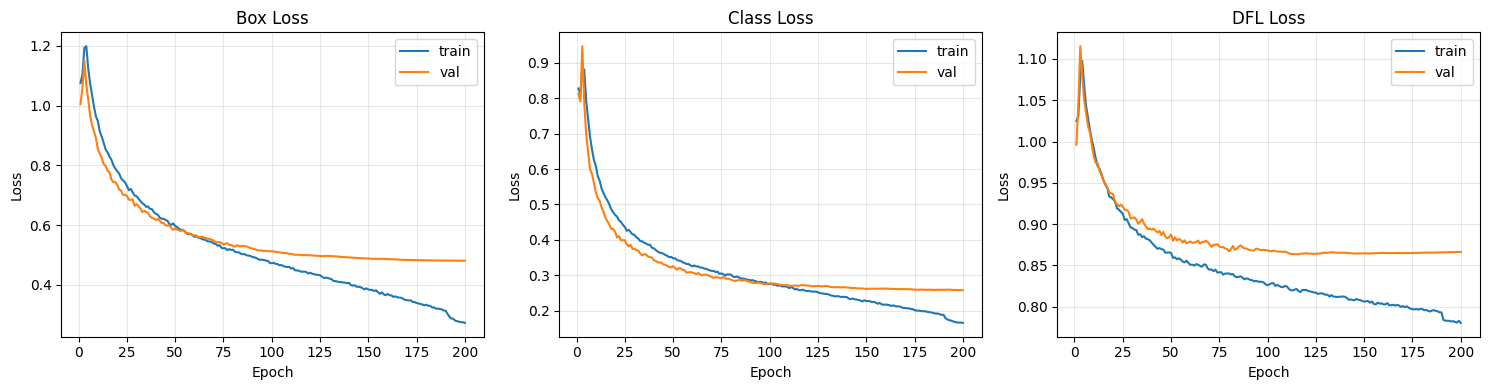

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

loss_pairs = [
    ("train/box_loss", "val/box_loss", "Box Loss"),
    ("train/cls_loss", "val/cls_loss", "Class Loss"),
    ("train/dfl_loss", "val/dfl_loss", "DFL Loss"),
]

for ax, (train_col, val_col, title) in zip(axes, loss_pairs):
    ax.plot(df["epoch"], df[train_col], label="train")
    ax.plot(df["epoch"], df[val_col], label="val")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

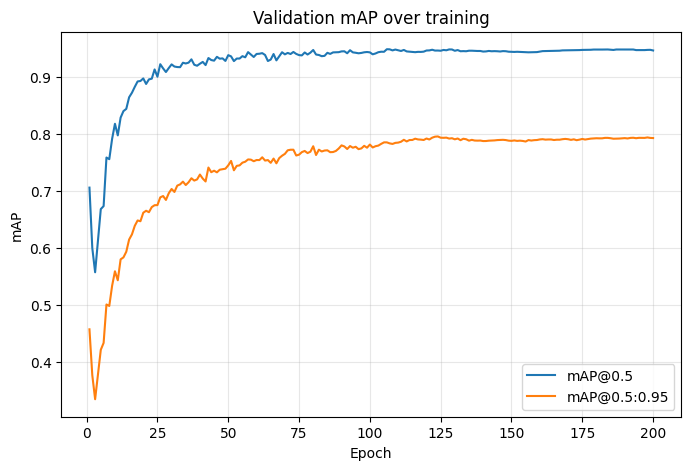

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5")
ax.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")
ax.set_xlabel("Epoch")
ax.set_ylabel("mAP")
ax.set_title("Validation mAP over training")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [ ]:
import shutil
from pathlib import Path

drive_dest = Path("/content/drive/MyDrive/kitti_runs")
drive_dest.mkdir(parents=True, exist_ok=True)

src = ROOT / "runs"  # /content/kitti/runs

# copytree needs the destination to not already exist as a subfolder target,
# so copy into a named subfolder under drive_dest
shutil.copytree(src, drive_dest / "runs", dirs_exist_ok=True)

print(f"Copied {src} to {drive_dest / 'runs'}")

Copied /content/kitti/runs to /content/drive/MyDrive/kitti_runs/runs


In [5]:
!pip install -q motmetrics
!git clone -q https://github.com/JonathonLuiten/TrackEval.git
!pip install ultralytics

fatal: destination path 'TrackEval' already exists and is not an empty directory.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 7.6 MB/s eta 0:00:00


In [16]:
from pathlib import Path

ROOT = Path("kitti")  # or wherever your extracted KITTI folders actually live

seq_id = "0000"
seq_img_dir = ROOT / "data_tracking_image_2" / "training" / "image_02" / seq_id

print(type(ROOT), ROOT)

<class 'pathlib.PosixPath'> kitti


In [18]:
import importlib
import lap
importlib.reload(lap)

<module 'lap' from '/usr/local/lib/python3.12/dist-packages/lap/__init__.py'>

In [19]:
import subprocess
subprocess.run(["pip", "install", "-q", "lap>=0.5.12"])

import sys
for mod in list(sys.modules):
    if mod.startswith("lap") or mod.startswith("ultralytics"):
        del sys.modules[mod]

from ultralytics import YOLO
model = YOLO("best.pt")

In [20]:
from ultralytics import YOLO
from pathlib import Path

ROOT = Path("kitti")  # adjust if your KITTI folders live elsewhere, e.g. Path("/content/kitti")

detector_weights = "best.pt"
model = YOLO(detector_weights)

# Pick one tracking sequence, e.g. 0000
seq_id = "0000"
seq_img_dir = ROOT / "data_tracking_image_2" / "training" / "image_02" / seq_id

print("Looking for sequence at:", seq_img_dir)
print("Exists:", seq_img_dir.exists())

results = model.track(
    source=str(seq_img_dir),
    tracker="bytetrack.yaml",   # or "botsort.yaml"
    persist=True,
    conf=0.25,
    verbose=False,
)

Looking for sequence at: kitti/data_tracking_image_2/training/image_02/0000
Exists: True


In [21]:
def write_mot_predictions(results, out_path):
    lines = []
    for frame_idx, r in enumerate(results):
        if r.boxes.id is None:
            continue
        for box, track_id in zip(r.boxes.xyxy.tolist(), r.boxes.id.tolist()):
            x1, y1, x2, y2 = box
            w, h = x2 - x1, y2 - y1
            lines.append(f"{frame_idx},{int(track_id)},{x1:.2f},{y1:.2f},{w:.2f},{h:.2f},1,1,1")
    Path(out_path).write_text("\n".join(lines))


def kitti_tracking_gt_to_mot(gt_path, out_path, target_classes=("Car",)):
    """KITTI tracking label_02 format: frame track_id type trunc occ alpha x1 y1 x2 y2 ..."""
    lines = []
    for line in Path(gt_path).read_text().splitlines():
        p = line.split()
        frame, track_id, cls = int(p[0]), int(p[1]), p[2]
        if cls not in target_classes or track_id == -1:
            continue
        x1, y1, x2, y2 = map(float, p[6:10])
        w, h = x2 - x1, y2 - y1
        lines.append(f"{frame},{track_id},{x1:.2f},{y1:.2f},{w:.2f},{h:.2f},1,1,1")
    Path(out_path).write_text("\n".join(lines))


pred_path = ROOT / "tracking_eval" / f"{seq_id}_pred.txt"
gt_path_out = ROOT / "tracking_eval" / f"{seq_id}_gt.txt"
pred_path.parent.mkdir(parents=True, exist_ok=True)

write_mot_predictions(results, pred_path)
kitti_tracking_gt_to_mot(
    ROOT / "data_tracking_label_2" / "training" / "label_02" / f"{seq_id}.txt",
    gt_path_out,
)

In [23]:
import numpy as np

if not hasattr(np, "asfarray"):
    np.asfarray = lambda a, dtype=np.float64: np.asarray(a, dtype=dtype)

import motmetrics as mm

In [24]:
import motmetrics as mm
import numpy as np

def load_mot_txt(path):
    data = {}
    for line in Path(path).read_text().splitlines():
        if not line.strip():
            continue
        frame, tid, x, y, w, h, *_ = line.split(",")
        data.setdefault(int(frame), []).append((int(tid), float(x), float(y), float(w), float(h)))
    return data

gt_data = load_mot_txt(gt_path_out)
pred_data = load_mot_txt(pred_path)

acc = mm.MOTAccumulator(auto_id=True)
for frame in sorted(set(gt_data) | set(pred_data)):
    gt_frame = gt_data.get(frame, [])
    pred_frame = pred_data.get(frame, [])

    gt_ids = [g[0] for g in gt_frame]
    pred_ids = [p[0] for p in pred_frame]
    gt_boxes = np.array([g[1:] for g in gt_frame]) if gt_frame else np.empty((0, 4))
    pred_boxes = np.array([p[1:] for p in pred_frame]) if pred_frame else np.empty((0, 4))

    dist_matrix = mm.distances.iou_matrix(gt_boxes, pred_boxes, max_iou=0.5)
    acc.update(gt_ids, pred_ids, dist_matrix)

mh = mm.metrics.create()
summary = mh.compute(acc, metrics=["mota", "motp", "num_switches"], name=seq_id)
print(summary)

          mota      motp  num_switches
0000 -1.193416  0.142175             1


In [25]:
# TrackEval expects a specific folder layout. This sets up minimal KITTI-format eval.
trackeval_root = Path("TrackEval")
data_dir = trackeval_root / "data" / "kitti" / "kitti_2d_box_train"
gt_dir = data_dir / "label_02"
pred_dir = trackeval_root / "data" / "trackers" / "kitti" / "kitti_2d_box_train" / "yolo11x_bytetrack" / "data"

gt_dir.mkdir(parents=True, exist_ok=True)
pred_dir.mkdir(parents=True, exist_ok=True)

shutil.copy2(gt_path_out, gt_dir / f"{seq_id}.txt")
shutil.copy2(pred_path, pred_dir / f"{seq_id}.txt")

# Running TrackEval's KITTI eval script from here requires its seqmap files and
# specific config — this is the part worth doing once you're evaluating multiple
# sequences, not just one. For a single-sequence sanity check, motmetrics above
# already gives you a real MOTA number to report.

PosixPath('TrackEval/data/trackers/kitti/kitti_2d_box_train/yolo11x_bytetrack/data/0000.txt')

In [26]:
!pip install -q transformers

from transformers import pipeline
import torch

depth_pipe = pipeline(
    task="depth-estimation",
    model="depth-anything/Depth-Anything-V2-Small-hf",
    device=0 if torch.cuda.is_available() else -1,
)

config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 99.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

In [27]:
def load_kitti_calib(calib_path):
    """Returns the P2 (3x4) projection matrix for the left color camera."""
    for line in Path(calib_path).read_text().splitlines():
        if line.startswith("P2:"):
            vals = list(map(float, line.split()[1:]))
            return np.array(vals).reshape(3, 4)
    raise ValueError("P2 not found in calib file")

In [28]:
def estimate_3d_from_2d(box_xyxy, depth_map, P2):
    """
    Rough 3D lift: sample depth at box centroid, back-project using camera intrinsics.
    This gives an approximate (x, y, z) location, not a full 3D box (no dimension/orientation estimate).
    """
    x1, y1, x2, y2 = box_xyxy
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2

    # Sample depth at a small patch around centroid, take median for robustness
    patch = depth_map[int(y1):int(y2), int(x1):int(x2)]
    z = np.median(patch) if patch.size > 0 else depth_map[int(cy), int(cx)]

    fx, fy = P2[0, 0], P2[1, 1]
    cx_intr, cy_intr = P2[0, 2], P2[1, 2]

    X = (cx - cx_intr) * z / fx
    Y = (cy - cy_intr) * z / fy
    Z = z

    return X, Y, Z


def compute_depth_and_3d(img_path, boxes_xyxy, calib_path):
    calib = load_kitti_calib(calib_path)
    depth_result = depth_pipe(str(img_path))
    depth_map = np.array(depth_result["depth"])

    positions = []
    for box in boxes_xyxy:
        X, Y, Z = estimate_3d_from_2d(box, depth_map, calib)
        positions.append((X, Y, Z))
    return positions

In [29]:
def load_kitti_3d_gt(label_path, target_classes=("Car",)):
    """Returns list of (class, x1,y1,x2,y2, h,w,l, tx,ty,tz, ry) from object detection labels."""
    gt = []
    for line in Path(label_path).read_text().splitlines():
        p = line.split()
        cls = p[0]
        if cls not in target_classes:
            continue
        x1, y1, x2, y2 = map(float, p[4:8])
        h, w, l = map(float, p[8:11])
        tx, ty, tz = map(float, p[11:14])
        gt.append({"box2d": (x1, y1, x2, y2), "dims": (h, w, l), "loc": (tx, ty, tz)})
    return gt


def position_error(pred_xyz, gt_xyz):
    return np.linalg.norm(np.array(pred_xyz) - np.array(gt_xyz))

In [33]:
def write_mot_predictions(results, out_path, model, target_class_names=("car",)):
    target_ids = {i for i, name in model.names.items() if name.lower() in target_class_names}
    lines = []
    for frame_idx, r in enumerate(results):
        if r.boxes.id is None:
            continue
        for box, track_id, cls in zip(r.boxes.xyxy.tolist(), r.boxes.id.tolist(), r.boxes.cls.tolist()):
            if int(cls) not in target_ids:
                continue
            x1, y1, x2, y2 = box
            w, h = x2 - x1, y2 - y1
            lines.append(f"{frame_idx},{int(track_id)},{x1:.2f},{y1:.2f},{w:.2f},{h:.2f},1,1,1")
    Path(out_path).write_text("\n".join(lines))


all_summaries = []

for seq_id in [f"{i:04d}" for i in range(21)]:
    seq_img_dir = ROOT / "data_tracking_image_2" / "training" / "image_02" / seq_id
    if not seq_img_dir.exists():
        continue

    results = model.track(source=str(seq_img_dir), tracker="bytetrack.yaml",
                          persist=True, conf=0.25, verbose=False)

    pred_path = ROOT / "tracking_eval" / f"{seq_id}_pred.txt"
    gt_path_out = ROOT / "tracking_eval" / f"{seq_id}_gt.txt"
    pred_path.parent.mkdir(parents=True, exist_ok=True)

    write_mot_predictions(results, pred_path, model, target_class_names=("car",))
    kitti_tracking_gt_to_mot(
        ROOT / "data_tracking_label_2" / "training" / "label_02" / f"{seq_id}.txt",
        gt_path_out,
    )

    gt_data = load_mot_txt(gt_path_out)
    pred_data = load_mot_txt(pred_path)

    n_gt_boxes = sum(len(v) for v in gt_data.values())
    if n_gt_boxes == 0:
        print(f"Skipping {seq_id}: no GT Cars in this sequence")
        continue

    acc = mm.MOTAccumulator(auto_id=True)
    for frame in sorted(set(gt_data) | set(pred_data)):
        gt_frame = gt_data.get(frame, [])
        pred_frame = pred_data.get(frame, [])
        gt_ids = [g[0] for g in gt_frame]
        pred_ids = [p[0] for p in pred_frame]
        gt_boxes = np.array([g[1:] for g in gt_frame]) if gt_frame else np.empty((0, 4))
        pred_boxes = np.array([p[1:] for p in pred_frame]) if pred_frame else np.empty((0, 4))
        dist_matrix = mm.distances.iou_matrix(gt_boxes, pred_boxes, max_iou=0.5)
        acc.update(gt_ids, pred_ids, dist_matrix)

    summary = mh.compute(acc, metrics=["mota", "motp", "num_switches"], name=seq_id)
    all_summaries.append(summary)
    print(summary)

import pandas as pd
full_results = pd.concat(all_summaries)
print("\n=== Averaged across sequences with GT Cars ===")
print(full_results.mean(numeric_only=True))

          mota      motp  num_switches
0000  0.238683  0.142175             1
          mota      motp  num_switches
0001  0.894069  0.132811             7
          mota     motp  num_switches
0002  0.756783  0.13485            12
          mota      motp  num_switches
0003  0.895317  0.140359             0
          mota      motp  num_switches
0004  0.837408  0.158705            58
          mota      motp  num_switches
0005  0.941961  0.116568            16
          mota      motp  num_switches
0006  0.727273  0.144151             0
          mota     motp  num_switches
0007  0.890168  0.12945            38
          mota      motp  num_switches
0008  0.924474  0.136493            15
          mota      motp  num_switches
0009  0.917454  0.132052            16
          mota     motp  num_switches
0010  0.933665  0.11261             5
          mota      motp  num_switches
0011  0.932746  0.107038            22
        mota      motp  num_switches
0012  0.9375  0.115537           

In [31]:
for seq_id in ["0013", "0016", "0017", "0019"]:
    gt_path_out = ROOT / "tracking_eval" / f"{seq_id}_gt.txt"
    gt_data = load_mot_txt(gt_path_out)
    n_gt = sum(len(v) for v in gt_data.values())
    print(f"{seq_id}: {n_gt} GT boxes")

0013: 55 GT boxes
0016: 836 GT boxes
0017: 0 GT boxes
0019: 927 GT boxes


In [34]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Reconstruct a clean dataframe from your all_summaries list
full_results = pd.concat(all_summaries)
full_results = full_results.reset_index().rename(columns={"index": "seq_id"})
full_results = full_results.sort_values("seq_id")

seq_ids = full_results["seq_id"]
mota = full_results["mota"]
motp = full_results["motp"]
switches = full_results["num_switches"]

avg_mota = mota.mean()
avg_motp = motp.mean()
avg_switches = switches.mean()

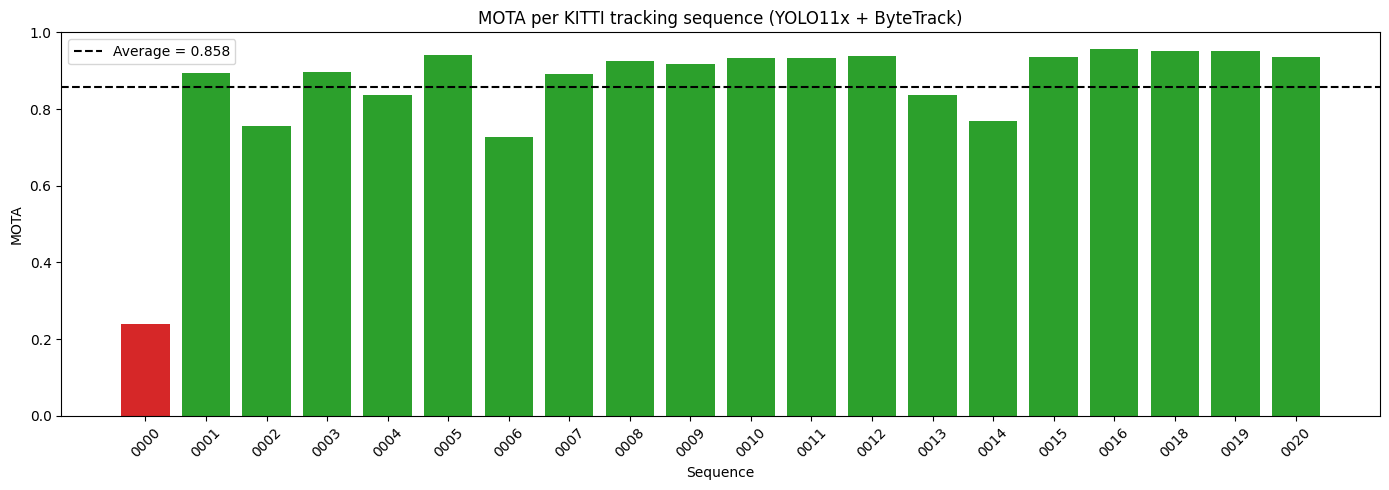

In [35]:
fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#d62728" if m < 0.5 else "#2ca02c" for m in mota]
ax.bar(seq_ids, mota, color=colors)
ax.axhline(avg_mota, color="black", linestyle="--", linewidth=1.5, label=f"Average = {avg_mota:.3f}")
ax.set_xlabel("Sequence")
ax.set_ylabel("MOTA")
ax.set_title("MOTA per KITTI tracking sequence (YOLO11x + ByteTrack)")
ax.set_ylim(0, 1)
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

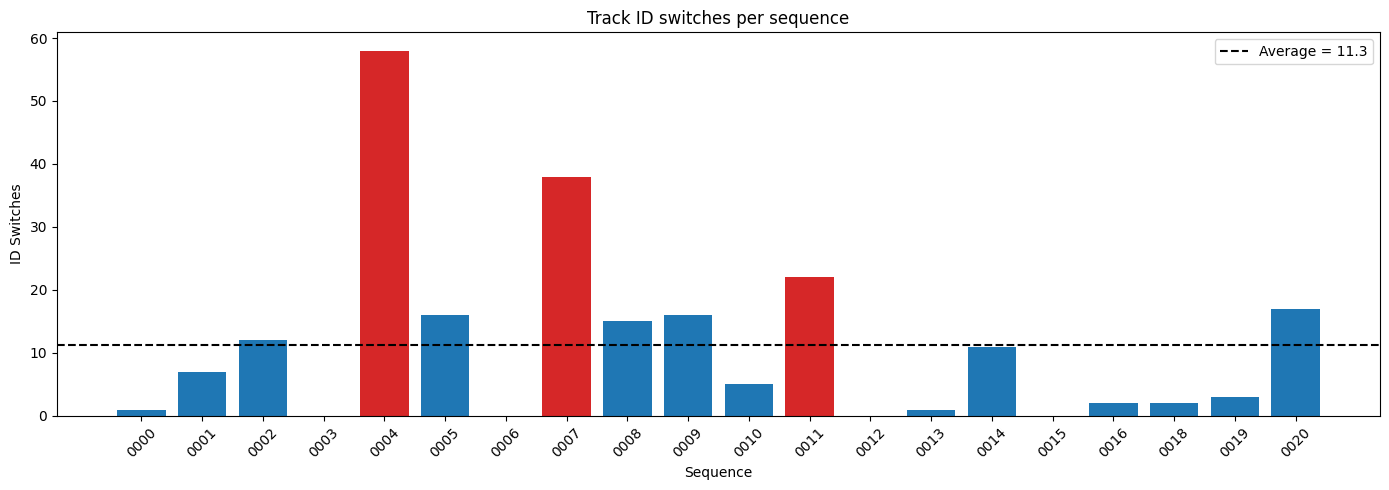

In [36]:
fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#d62728" if s > 20 else "#1f77b4" for s in switches]
ax.bar(seq_ids, switches, color=colors)
ax.axhline(avg_switches, color="black", linestyle="--", linewidth=1.5, label=f"Average = {avg_switches:.1f}")
ax.set_xlabel("Sequence")
ax.set_ylabel("ID Switches")
ax.set_title("Track ID switches per sequence")
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

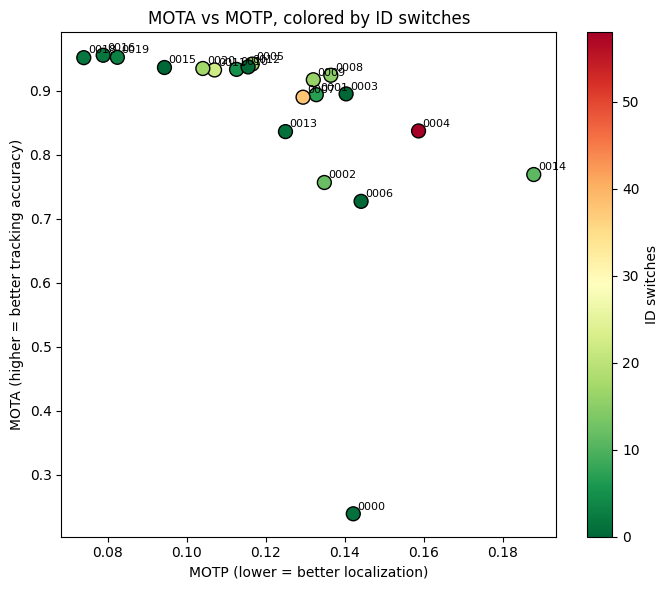

In [37]:
fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(motp, mota, c=switches, cmap="RdYlGn_r", s=100, edgecolor="black")
for i, seq in enumerate(seq_ids):
    ax.annotate(seq, (motp.iloc[i], mota.iloc[i]), fontsize=8, xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("MOTP (lower = better localization)")
ax.set_ylabel("MOTA (higher = better tracking accuracy)")
ax.set_title("MOTA vs MOTP, colored by ID switches")
cbar = plt.colorbar(scatter)
cbar.set_label("ID switches")
plt.tight_layout()
plt.show()

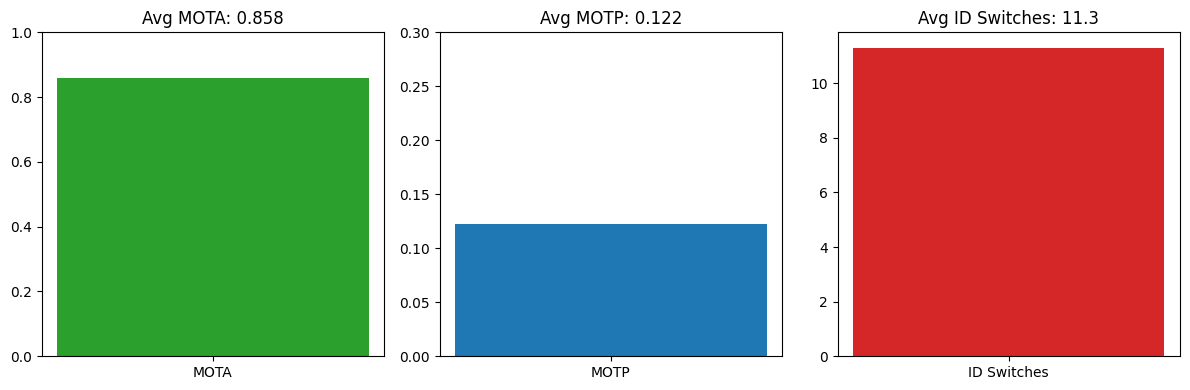

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].bar(["MOTA"], [avg_mota], color="#2ca02c")
axes[0].set_ylim(0, 1)
axes[0].set_title(f"Avg MOTA: {avg_mota:.3f}")

axes[1].bar(["MOTP"], [avg_motp], color="#1f77b4")
axes[1].set_ylim(0, max(0.3, avg_motp * 1.5))
axes[1].set_title(f"Avg MOTP: {avg_motp:.3f}")

axes[2].bar(["ID Switches"], [avg_switches], color="#d62728")
axes[2].set_title(f"Avg ID Switches: {avg_switches:.1f}")

plt.tight_layout()
plt.show()

In [39]:
from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else -1

depth_pipe = pipeline(
    task="depth-estimation",
    model="depth-anything/Depth-Anything-V2-Small-hf",
    device=device,
)
print("Depth model loaded on:", "cuda" if device == 0 else "cpu")

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

Depth model loaded on: cuda


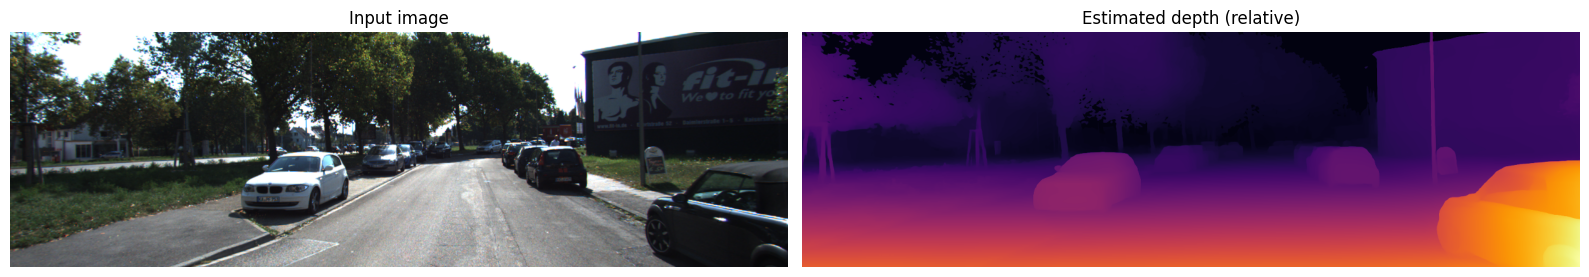

In [40]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img_id = "000010"  # any KITTI object detection image
img_path = ROOT / "data_object_image_2" / "training" / "image_2" / f"{img_id}.png"

img = Image.open(img_path)
depth_result = depth_pipe(img)
depth_map = np.array(depth_result["depth"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].imshow(img)
axes[0].set_title("Input image")
axes[0].axis("off")
axes[1].imshow(depth_map, cmap="inferno")
axes[1].set_title("Estimated depth (relative)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [59]:
depth_pipe_metric = pipeline(
    task="depth-estimation",
    model="depth-anything/Depth-Anything-V2-Metric-Outdoor-Large-hf",  # or Outdoor variant
    device=device,
)

Loading weights:   0%|          | 0/503 [00:00<?, ?it/s]

In [53]:
from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else -1

depth_pipe = pipeline(
    task="depth-estimation",
    model="depth-anything/Depth-Anything-V2-Metric-Outdoor-Large-hf",
    device=device,
)
print("Metric depth model loaded on:", "cuda" if device == 0 else "cpu")

config.json:   0%|          | 0.00/1.54k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.34GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/503 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/437 [00:00<?, ?B/s]

Metric depth model loaded on: cuda


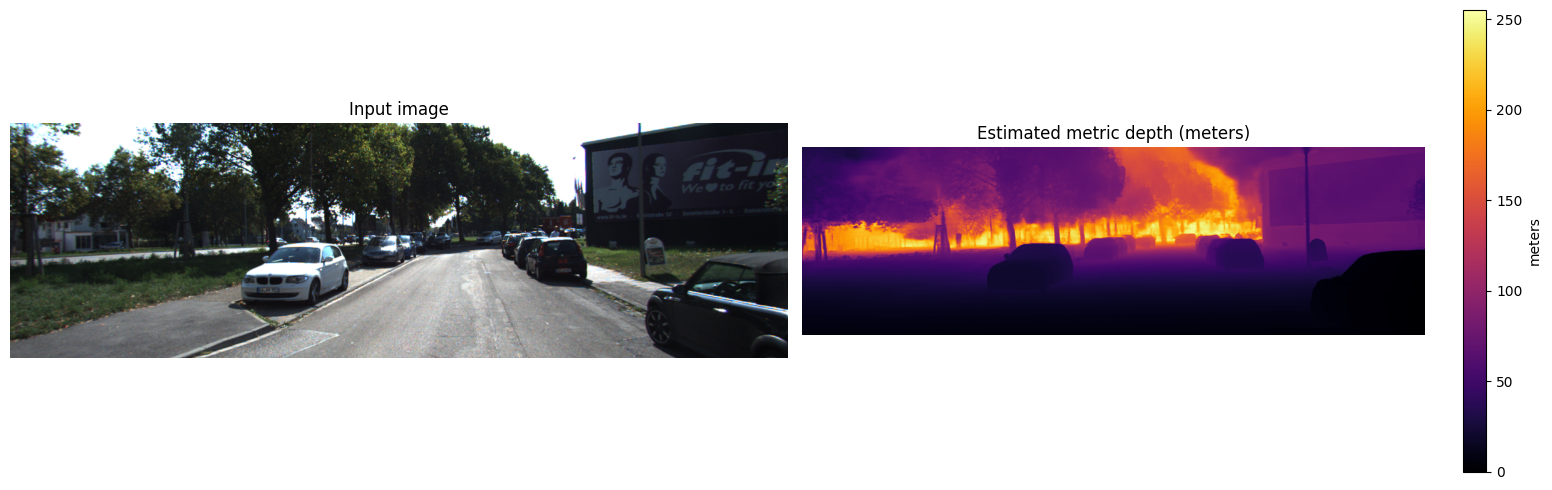

Depth range: 0.0m - 255.0m


In [60]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img_id = "000010"
img_path = ROOT / "data_object_image_2" / "training" / "image_2" / f"{img_id}.png"

img = Image.open(img_path)
depth_result = depth_pipe(img)
depth_map = np.array(depth_result["depth"])  # in meters

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].imshow(img)
axes[0].set_title("Input image")
axes[0].axis("off")
im = axes[1].imshow(depth_map, cmap="inferno")
axes[1].set_title("Estimated metric depth (meters)")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], label="meters")
plt.tight_layout()
plt.show()

print(f"Depth range: {depth_map.min():.1f}m - {depth_map.max():.1f}m")

In [61]:
def load_kitti_calib(calib_path):
    """Returns the P2 (3x4) projection matrix for the left color camera."""
    for line in Path(calib_path).read_text().splitlines():
        if line.startswith("P2:"):
            vals = list(map(float, line.split()[1:]))
            return np.array(vals).reshape(3, 4)
    raise ValueError("P2 not found in calib file")


calib_path = ROOT / "data_object_calib" / "training" / "calib" / f"{img_id}.txt"
P2 = load_kitti_calib(calib_path)
print(P2)

[[     721.54           0      609.56      44.857]
 [          0      721.54      172.85     0.21638]
 [          0           0           1   0.0027459]]


In [62]:
def load_kitti_3d_gt(label_path, target_classes=("Car",)):
    gt = []
    for line in Path(label_path).read_text().splitlines():
        p = line.split()
        cls = p[0]
        if cls not in target_classes:
            continue
        x1, y1, x2, y2 = map(float, p[4:8])
        h, w, l = map(float, p[8:11])
        tx, ty, tz = map(float, p[11:14])
        gt.append({
            "box2d": (x1, y1, x2, y2),
            "dims": (h, w, l),
            "loc": (tx, ty, tz),  # camera coordinates, meters
        })
    return gt


label_path = ROOT / "data_object_label_2" / "training" / "label_2" / f"{img_id}.txt"
gt_objects = load_kitti_3d_gt(label_path)
print(f"Found {len(gt_objects)} Car(s) in ground truth")
for obj in gt_objects:
    print(obj)

Found 8 Car(s) in ground truth
{'box2d': (1013.39, 182.46, 1241.0, 374.0), 'dims': (1.57, 1.65, 3.35), 'loc': (4.43, 1.65, 5.2)}
{'box2d': (354.43, 185.52, 549.52, 294.49), 'dims': (1.43, 1.7, 3.95), 'loc': (-2.39, 1.66, 11.8)}
{'box2d': (819.63, 178.12, 926.85, 251.56), 'dims': (1.51, 1.6, 3.24), 'loc': (5.85, 1.64, 16.5)}
{'box2d': (800.54, 178.06, 878.75, 230.56), 'dims': (1.45, 1.74, 4.1), 'loc': (6.87, 1.62, 22.05)}
{'box2d': (558.55, 179.04, 635.05, 230.61), 'dims': (1.54, 1.68, 3.79), 'loc': (-0.38, 1.76, 23.64)}
{'box2d': (598.3, 178.68, 652.25, 218.17), 'dims': (1.49, 1.52, 3.35), 'loc': (0.64, 1.74, 29.07)}
{'box2d': (784.59, 178.04, 839.98, 220.1), 'dims': (1.53, 1.65, 4.37), 'loc': (7.88, 1.75, 28.53)}
{'box2d': (663.74, 175.36, 707.21, 204.15), 'dims': (1.64, 1.45, 3.48), 'loc': (4.5, 1.8, 42.85)}


In [63]:
def estimate_3d_from_2d(box_xyxy, depth_map, P2, shrink=0.5):
    x1, y1, x2, y2 = box_xyxy
    # Shrink box toward center to avoid edge/background contamination
    cx_box, cy_box = (x1 + x2) / 2, (y1 + y2) / 2
    half_w, half_h = (x2 - x1) / 2 * shrink, (y2 - y1) / 2 * shrink
    x1s, x2s = cx_box - half_w, cx_box + half_w
    y1s, y2s = cy_box - half_h, cy_box + half_h

    x1s, y1s = max(0, int(x1s)), max(0, int(y1s))
    x2s, y2s = min(depth_map.shape[1], int(x2s)), min(depth_map.shape[0], int(y2s))

    patch = depth_map[y1s:y2s, x1s:x2s]
    z = float(np.median(patch)) if patch.size > 0 else float(depth_map[int(cy_box), int(cx_box)])

    fx, fy = P2[0, 0], P2[1, 1]
    cx_intr, cy_intr = P2[0, 2], P2[1, 2]
    X = (cx_box - cx_intr) * z / fx
    Y = (cy_box - cy_intr) * z / fy
    return X, Y, z


for obj in gt_objects:
    pred_xyz = estimate_3d_from_2d(obj["box2d"], depth_map, P2)
    gt_xyz = obj["loc"]
    error = np.linalg.norm(np.array(pred_xyz) - np.array(gt_xyz))
    print(f"GT loc: {gt_xyz}  |  Predicted: {tuple(round(v,2) for v in pred_xyz)}  |  Error: {error:.2f}m")

GT loc: (4.43, 1.65, 5.2)  |  Predicted: (np.float64(2.15), np.float64(0.44), 3.0)  |  Error: 3.39m
GT loc: (-2.39, 1.66, 11.8)  |  Predicted: (np.float64(-4.8), np.float64(2.05), 22.0)  |  Error: 10.49m
GT loc: (5.85, 1.64, 16.5)  |  Predicted: (np.float64(13.16), np.float64(2.09), 36.0)  |  Error: 20.83m
GT loc: (6.87, 1.62, 22.05)  |  Predicted: (np.float64(13.07), np.float64(1.79), 41.0)  |  Error: 19.94m
GT loc: (-0.38, 1.76, 23.64)  |  Predicted: (np.float64(-1.18), np.float64(2.97), 67.0)  |  Error: 43.38m
GT loc: (0.64, 1.74, 29.07)  |  Predicted: (np.float64(1.68), np.float64(2.73), 77.0)  |  Error: 47.95m
GT loc: (7.88, 1.75, 28.53)  |  Predicted: (np.float64(17.98), np.float64(2.33), 64.0)  |  Error: 36.88m
GT loc: (4.5, 1.8, 42.85)  |  Predicted: (np.float64(14.2), np.float64(3.16), 135.0)  |  Error: 92.67m


In [64]:
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

processor = AutoImageProcessor.from_pretrained("depth-anything/Depth-Anything-V2-Metric-Outdoor-Large-hf")
model = AutoModelForDepthEstimation.from_pretrained("depth-anything/Depth-Anything-V2-Metric-Outdoor-Large-hf").to("cuda")

inputs = processor(images=img, return_tensors="pt").to("cuda")
with torch.no_grad():
    outputs = model(**inputs)
    predicted_depth = outputs.predicted_depth

# Resize back to original image size for pixel-accurate lookup
depth_map = torch.nn.functional.interpolate(
    predicted_depth.unsqueeze(1),
    size=img.size[::-1],  # (height, width)
    mode="bicubic",
    align_corners=False,
).squeeze().cpu().numpy()

Loading weights:   0%|          | 0/503 [00:00<?, ?it/s]

In [65]:
# Reuse the shrink-box estimator for better accuracy at range
def estimate_3d_from_2d(box_xyxy, depth_map, P2, shrink=0.5):
    x1, y1, x2, y2 = box_xyxy
    cx_box, cy_box = (x1 + x2) / 2, (y1 + y2) / 2
    half_w, half_h = (x2 - x1) / 2 * shrink, (y2 - y1) / 2 * shrink
    x1s, x2s = cx_box - half_w, cx_box + half_w
    y1s, y2s = cy_box - half_h, cy_box + half_h

    x1s, y1s = max(0, int(x1s)), max(0, int(y1s))
    x2s, y2s = min(depth_map.shape[1], int(x2s)), min(depth_map.shape[0], int(y2s))

    patch = depth_map[y1s:y2s, x1s:x2s]
    z = float(np.median(patch)) if patch.size > 0 else float(depth_map[int(cy_box), int(cx_box)])

    fx, fy = P2[0, 0], P2[1, 1]
    cx_intr, cy_intr = P2[0, 2], P2[1, 2]
    X = (cx_box - cx_intr) * z / fx
    Y = (cy_box - cy_intr) * z / fy
    return X, Y, z


print(f"Depth map shape: {depth_map.shape}  (should match image size: {img.size[1]}x{img.size[0]})")
print(f"Depth range: {depth_map.min():.1f}m - {depth_map.max():.1f}m\n")

for obj in gt_objects:
    pred_xyz = estimate_3d_from_2d(obj["box2d"], depth_map, P2)
    gt_xyz = obj["loc"]
    error = np.linalg.norm(np.array(pred_xyz) - np.array(gt_xyz))
    gt_dist = gt_xyz[2]
    print(f"GT dist: {gt_dist:5.1f}m  |  GT loc: {gt_xyz}  |  Predicted: {tuple(round(v,2) for v in pred_xyz)}  |  Error: {error:.2f}m")

Depth map shape: (375, 1242)  (should match image size: 375x1242)
Depth range: 4.6m - 78.3m

GT dist:   5.2m  |  GT loc: (4.43, 1.65, 5.2)  |  Predicted: (np.float64(3.97), np.float64(0.81), 5.54)  |  Error: 1.02m
GT dist:  11.8m  |  GT loc: (-2.39, 1.66, 11.8)  |  Predicted: (np.float64(-2.4), np.float64(1.02), 10.98)  |  Error: 1.04m
GT dist:  16.5m  |  GT loc: (5.85, 1.64, 16.5)  |  Predicted: (np.float64(5.57), np.float64(0.89), 15.25)  |  Error: 1.49m
GT dist:  22.1m  |  GT loc: (6.87, 1.62, 22.05)  |  Predicted: (np.float64(5.25), np.float64(0.72), 16.47)  |  Error: 5.88m
GT dist:  23.6m  |  GT loc: (-0.38, 1.76, 23.64)  |  Predicted: (np.float64(-0.43), np.float64(1.07), 24.18)  |  Error: 0.88m
GT dist:  29.1m  |  GT loc: (0.64, 1.74, 29.07)  |  Predicted: (np.float64(0.59), np.float64(0.96), 27.09)  |  Error: 2.13m
GT dist:  28.5m  |  GT loc: (7.88, 1.75, 28.53)  |  Predicted: (np.float64(6.56), np.float64(0.85), 23.35)  |  Error: 5.42m
GT dist:  42.9m  |  GT loc: (4.5, 1.8, 42

In [66]:
import random

def evaluate_depth_on_images(img_ids, depth_pipe_large=None):
    """Run depth + 3D lift across many images, return all (gt_dist, error) pairs."""
    all_results = []

    for img_id in img_ids:
        img_path = ROOT / "data_object_image_2" / "training" / "image_2" / f"{img_id}.png"
        calib_path = ROOT / "data_object_calib" / "training" / "calib" / f"{img_id}.txt"
        label_path = ROOT / "data_object_label_2" / "training" / "label_2" / f"{img_id}.txt"

        if not (img_path.exists() and calib_path.exists() and label_path.exists()):
            continue

        gt_objects = load_kitti_3d_gt(label_path)
        if not gt_objects:
            continue

        img = Image.open(img_path)
        P2 = load_kitti_calib(calib_path)

        inputs = processor(images=img, return_tensors="pt").to("cuda")
        with torch.no_grad():
            outputs = model(**inputs)
            predicted_depth = outputs.predicted_depth

        depth_map = torch.nn.functional.interpolate(
            predicted_depth.unsqueeze(1),
            size=img.size[::-1],
            mode="bicubic",
            align_corners=False,
        ).squeeze().cpu().numpy()

        for obj in gt_objects:
            pred_xyz = estimate_3d_from_2d(obj["box2d"], depth_map, P2)
            gt_xyz = obj["loc"]
            error = np.linalg.norm(np.array(pred_xyz) - np.array(gt_xyz))
            all_results.append({"img_id": img_id, "gt_dist": gt_xyz[2], "error": error})

    return pd.DataFrame(all_results)


# Sample a random set of images (adjust n as needed — 100+ is a solid sample)
all_label_files = sorted((ROOT / "data_object_label_2" / "training" / "label_2").glob("*.txt"))
sample_ids = [f.stem for f in random.sample(all_label_files, min(100, len(all_label_files)))]

depth_results_df = evaluate_depth_on_images(sample_ids)
print(f"Evaluated {len(depth_results_df)} object instances across {depth_results_df['img_id'].nunique()} images")

Evaluated 418 object instances across 90 images


In [67]:
bins = [0, 10, 20, 30, 50, 100]
depth_results_df["dist_bin"] = pd.cut(depth_results_df["gt_dist"], bins=bins)

summary = depth_results_df.groupby("dist_bin")["error"].agg(["mean", "median", "std", "count"])
print(summary)

               mean    median       std  count
dist_bin                                      
(0, 10]    2.028413  1.325751  2.177140     55
(10, 20]   2.221108  1.551924  2.059975    104
(20, 30]   2.825273  1.934657  2.489795     91
(30, 50]   4.874854  3.475542  4.205757    126
(50, 100]  8.647124  7.017392  8.353747     42


/tmp/ipykernel_2615/3730572516.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = depth_results_df.groupby("dist_bin")["error"].agg(["mean", "median", "std", "count"])


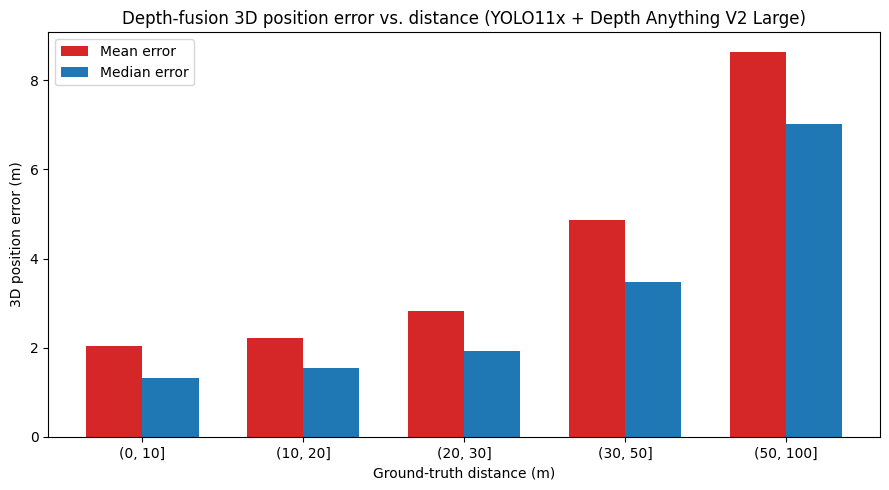

In [68]:
import matplotlib.pyplot as plt

bin_labels = [str(b) for b in summary.index]
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(bin_labels))
width = 0.35

ax.bar(x - width/2, summary["mean"], width, label="Mean error", color="#d62728")
ax.bar(x + width/2, summary["median"], width, label="Median error", color="#1f77b4")
ax.set_xticks(x)
ax.set_xticklabels(bin_labels)
ax.set_xlabel("Ground-truth distance (m)")
ax.set_ylabel("3D position error (m)")
ax.set_title("Depth-fusion 3D position error vs. distance (YOLO11x + Depth Anything V2 Large)")
ax.legend()
plt.tight_layout()
plt.show()